In [31]:
import pandas as pd
import numpy as np
import os

import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import plotly.express as px

In [32]:
# Create output folder
os.makedirs("output", exist_ok=True)

# Set style
sns.set(style="whitegrid")

In [33]:
sample_info = pd.read_csv("input/sample_info_completed.tsv", sep="\t")
sample_info = sample_info[[
        "Sample ID",
        "TP",
        "Sex",
        "CF ID",
        "cancer_type",
        "stage",
        "toxicity_first_date",
        "toxicity",
        "country",
        "PPI",
        "Cortisone",
        "NSAID",
        "Asprin",
        "AB"
    ]]

meta = pd.read_csv("input/meta.tsv", sep="\t")
quant = pd.read_csv("input/plasma_prot_quant.tsv", sep="\t")

# correct long gene names
quant["PG.Genes"] = quant["PG.Genes"].apply(
    lambda x: f"{x.split(';')[0]} genes" if isinstance(x, str) and ";" in x else x
)

/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_99826/2225047822.py:20: DtypeWarning: Columns (0: [254] XCHEJF1-254_20250824_plasma_S254_250ng_41p5min_DIA_r2.raw.PG.MS1Quantity, 1: [254] XCHEJF1-254_20250824_plasma_S254_250ng_41p5min_DIA_r2.raw.PG.MS2Quantity) have mixed types. Specify dtype option on import or set low_memory=False.
  quant = pd.read_csv("input/plasma_prot_quant.tsv", sep="\t")


In [34]:
# Build mapping: R.FileName → CF ID
mapping = dict(zip(meta["R.FileName"], meta["Sample ID"]))

quant_cols = quant.columns[1:]  # exclude PG.Genes

col_to_cf = {}
for col in quant_cols:
    for rfile, cfid in mapping.items():
        if rfile in col:
            col_to_cf[col] = cfid
            break

# Keep mapped columns only
quant_filtered = quant[list(col_to_cf.keys())]

# Rename columns → CF IDs
quant_filtered = quant_filtered.rename(columns=col_to_cf)

# Keep PG.Genes
quant_filtered = quant[["PG.Genes"] + list(col_to_cf.keys())]

# Set protein names as index
quant_filtered = quant_filtered.set_index("PG.Genes")

# Rename columns → CF IDs
quant_filtered = quant_filtered.rename(columns=col_to_cf)

In [35]:
# Transpose → samples as rows, proteins as columns
expr = quant_filtered.T
# Remove duplicated samples
expr = expr[~expr.index.duplicated(keep="first")]
# Ensure numeric
expr = expr.apply(pd.to_numeric, errors="coerce")
# Log2 transform (if needed)
expr = np.log2(expr + 1)
expr.columns = pd.Index(expr.columns).map(str)
expr = expr.loc[:, ~expr.columns.duplicated()]

In [36]:
data = expr.merge(sample_info, left_index=True, right_on="CF ID")
data = data.set_index("CF ID")

# Extract Country
data["Country"] = data["Sample ID"].str[:3]
data

,ARF5,FUCA2,SEMA3F,CEACAM7,KRT33A,CD9,CPA1,CD4,PPP5C,NME1,...,stage,toxicity_first_date,toxicity,country,PPI,Cortisone,NSAID,Asprin,AB,Country
CF ID,,,,,,,,,,,,,,,,,,,,,
XCHEJF_001,1.0,3.169925,1.584963,0.0,0.000000,2.000000,2.000000,1.0,0.0,1.000000,...,Others,NaN,no,SWE,NaN,NaN,NaN,NaN,NaN,SWE
XCHEJF_001,1.0,3.169925,1.584963,0.0,0.000000,2.000000,2.000000,1.0,0.0,1.000000,...,Others,NaN,no,SWE,NaN,NaN,NaN,NaN,NaN,SWE
XCHEJF_002,0.0,3.169925,1.584963,0.0,0.000000,1.000000,2.584963,1.0,0.0,1.000000,...,Others,NaN,no,SWE,NaN,NaN,NaN,NaN,NaN,SWE
XCHEJF_002,0.0,3.169925,1.584963,0.0,0.000000,1.000000,2.584963,1.0,0.0,1.000000,...,Others,NaN,no,SWE,NaN,NaN,NaN,NaN,NaN,SWE
XCHEJF_003,0.0,3.000000,1.584963,0.0,0.000000,1.584963,1.584963,1.0,0.0,1.000000,...,IV,NaN,no,SWE,0.0,1.0,0.0,0.0,0.0,SWE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
XCHEJF_241,0.0,2.807355,1.000000,0.0,2.321928,0.000000,2.000000,1.0,0.0,1.000000,...,IV,29/03/2021,yes,ITA,0.0,1.0,0.0,0.0,0.0,ITA
XCHEJF_244,0.0,3.000000,2.000000,0.0,0.000000,0.000000,2.000000,1.0,0.0,1.584963,...,IV,19/07/2021,yes,ITA,1.0,1.0,1.0,0.0,1.0,ITA
XCHEJF_245,0.0,3.169925,1.584963,1.0,0.000000,0.000000,0.000000,1.0,0.0,1.584963,...,IV,22/09/2021,yes,ITA,NaN,NaN,NaN,NaN,NaN,ITA


In [37]:
design_df = data[[
    "Sex",
    "TP",
    "cancer_type",
    "country"
]].copy()

# Encode Sex (M=1, F=0)
design_df["Sex"] = design_df["Sex"].map({"M": 1, "F": 0})

# Medications
#binary_cols = ["PPI", "Cortisone", "NSAID", "Asprin", "AB"]
#for col in binary_cols:
#    design_df[col] = pd.to_numeric(design_df[col], errors="coerce")

# One-hot encode
design_df = pd.get_dummies(
    design_df,
    columns=["TP", "cancer_type", "country"],
    drop_first=True
)

# Ensure numeric
design_df = design_df.apply(pd.to_numeric, errors="coerce")
design_df

,Sex,TP_T1,TP_T2,cancer_type_Lung,cancer_type_Melanoma,country_ITA,country_NOR,country_SWE
CF ID,,,,,,,,
XCHEJF_001,1.0,False,False,False,True,False,False,True
XCHEJF_001,1.0,False,False,False,True,False,False,True
XCHEJF_002,NaN,True,False,False,True,False,False,True
XCHEJF_002,NaN,True,False,False,True,False,False,True
XCHEJF_003,1.0,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...
XCHEJF_241,0.0,False,False,False,False,True,False,False
XCHEJF_244,0.0,False,False,False,False,True,False,False
XCHEJF_245,0.0,False,False,True,False,True,False,False


__Linear Modelling (OLS)__

Protein ~ Sex + TP + cancer_type + country

	•	Sex = effect of interest
	•	everything else = confounders / covariates

In [38]:
expr = expr[~expr.index.duplicated(keep="first")]
design_df = design_df[~design_df.index.duplicated(keep="first")]

common_idx = expr.index.intersection(design_df.index)

expr = expr.loc[common_idx]

# proportion of non-missing values per protein (column)
detection_rate = expr.notna().mean(axis=0)
# keep proteins detected in at least 80% of samples
keep_proteins = detection_rate[detection_rate >= 0.8].index
print(f"Number of proteins in 80% of samples: {len(keep_proteins)}")
print(f"Total proteins before filtering: {expr.shape[1]}")
# filtered expression matrix (same format as original)
expr = expr[keep_proteins]
design_df = design_df.loc[common_idx]

Number of proteins in 80% of samples: 2000
Total proteins before filtering: 2000


In [39]:
results = []

for protein in expr.columns:
    y = expr[protein]

    df_model = pd.concat([y, design_df], axis=1)

    # Clean all together
    df_model = df_model.apply(pd.to_numeric, errors="coerce").dropna()

    if df_model.shape[0] < 10:
        continue

    y_clean = df_model.iloc[:, 0].astype(float)
    X_clean = df_model.iloc[:, 1:].astype(float)

    # Add intercept
    X_clean = sm.add_constant(X_clean)

    model = sm.OLS(y_clean.values, X_clean.values)
    fit = model.fit()

    # Extract Sex effect safely
    col_names = X_clean.columns.tolist()
    if "Sex" not in col_names:
        continue

    sex_idx = col_names.index("Sex")

    coef = fit.params[sex_idx]
    pval = fit.pvalues[sex_idx]
    r2 = fit.rsquared
    r2_adj = fit.rsquared_adj

    results.append([protein, coef, pval, r2, r2_adj])

res_df = pd.DataFrame(results, columns=["Protein", "log2FC", "pvalue", "R_squared", "adj_R_squared"])

# Apply BH correction
# Remove invalid values
res_df = res_df.replace([np.inf, -np.inf], np.nan)
res_df = res_df.dropna(subset=["pvalue"])
res_df = res_df[res_df["pvalue"] > 0]
res_df["adj_pvalue"] = multipletests(
    res_df["pvalue"],
    method="fdr_bh"
)[1]

res_df.sort_values("adj_pvalue", inplace=True)
res_df

/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


,Protein,log2FC,pvalue,R_squared,adj_R_squared,adj_pvalue
415,CDHR2,1.316533,3.243387e-08,0.276065,0.222932,0.000065
388,PZP,-0.683626,4.694450e-06,0.197213,0.138293,0.004669
1172,GGT7,0.472612,5.782746e-05,0.258375,0.203944,0.038340
1751,GGT1,0.651995,7.989722e-05,0.175520,0.115008,0.039729
785,MMP3,0.633393,1.789007e-04,0.178986,0.118728,0.040390
...,...,...,...,...,...,...
1238,DPM3,0.000305,9.961670e-01,0.051607,-0.018000,0.999829
1477,PTGDS genes,0.000056,9.984754e-01,0.051210,-0.018426,0.999829
1696,IGHV3-38,-0.000274,9.970499e-01,0.083937,0.016703,0.999829
728,NCSTN,0.000039,9.992818e-01,0.228712,0.172104,0.999829


In [40]:
# Thresholds
fc_thresh = 0.25
p_thresh = 0.05

# Add -log10 p-values
res_df["-log10_p"] = -np.log10(res_df["adj_pvalue"])

# Define categories
def categorize(row):
    if row["adj_pvalue"] < p_thresh and row["log2FC"] > fc_thresh:
        return "Enriched in Men"
    elif row["adj_pvalue"] < p_thresh and row["log2FC"] < -fc_thresh:
        return "Enriched in Women"
    else:
        return "Non-significant"

res_df["category"] = res_df.apply(categorize, axis=1)



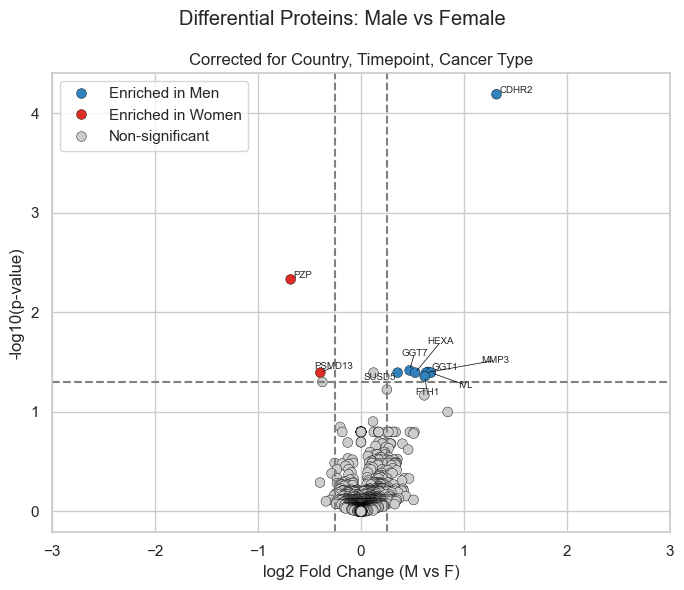

In [41]:
palette = {
    "Enriched in Men": "#3182bd",   # blue
    "Enriched in Women": "#de2d26", # red
    "Non-significant": "#cccccc"         # grey
}

plt.figure(figsize=(7,6))

sns.scatterplot(
    data=res_df,
    x="log2FC",
    y="-log10_p",
    hue="category",
    palette=palette,
    s=50,
    edgecolor="black",
    linewidth=0.3
)

# Threshold lines
plt.axhline(-np.log10(p_thresh), linestyle="--", color="grey")
plt.axvline(fc_thresh, linestyle="--", color="grey")
plt.axvline(-fc_thresh, linestyle="--", color="grey")
plt.xlim(-3, 3)
plt.xlabel("log2 Fold Change (M vs F)")
plt.ylabel("-log10(adj. p-value)")
plt.title("Differential Proteins: Men vs Women")

plt.legend(title="", loc="upper right")

label_df = res_df[
    (res_df["adj_pvalue"] < p_thresh) &
    (abs(res_df["log2FC"]) > fc_thresh)
].copy()

texts = []

for _, row in label_df.iterrows():
    texts.append(
        plt.text(
            row["log2FC"],
            row["-log10_p"],
            row["Protein"],
            fontsize=7
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
    expand_text=(1.4, 1.6),
    expand_points=(1.2, 1.4),
    force_text=(0.5, 0.8),
    force_points=(0.2, 0.5),
    only_move={"text": "xy"}
)


plt.xlabel("log2 Fold Change (M vs F)")
plt.ylabel("-log10(p-value)")
plt.suptitle("Differential Proteins: Male vs Female")
plt.title("Corrected for Country, Timepoint, Cancer Type")

# Move legend to upper left (as requested)
plt.legend(title="", loc="upper left")

plt.tight_layout()

plt.savefig("output/ols_volcano/volcano_M_vs_F.png", dpi=300)
plt.savefig("output/ols_volcano/volcano_M_vs_F.pdf")

plt.show()

In [42]:
res_df

,Protein,log2FC,pvalue,R_squared,adj_R_squared,adj_pvalue,-log10_p,category
415,CDHR2,1.316533,3.243387e-08,0.276065,0.222932,0.000065,4.190366,Enriched in Men
388,PZP,-0.683626,4.694450e-06,0.197213,0.138293,0.004669,2.330810,Enriched in Women
1172,GGT7,0.472612,5.782746e-05,0.258375,0.203944,0.038340,1.416352,Enriched in Men
1751,GGT1,0.651995,7.989722e-05,0.175520,0.115008,0.039729,1.400894,Enriched in Men
785,MMP3,0.633393,1.789007e-04,0.178986,0.118728,0.040390,1.393728,Enriched in Men
...,...,...,...,...,...,...,...,...
1238,DPM3,0.000305,9.961670e-01,0.051607,-0.018000,0.999829,0.000074,Non-significant
1477,PTGDS genes,0.000056,9.984754e-01,0.051210,-0.018426,0.999829,0.000074,Non-significant
1696,IGHV3-38,-0.000274,9.970499e-01,0.083937,0.016703,0.999829,0.000074,Non-significant
728,NCSTN,0.000039,9.992818e-01,0.228712,0.172104,0.999829,0.000074,Non-significant


In [43]:
res_df = res_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["pvalue", "log2FC"])
fig = px.scatter(
    res_df,
    x="log2FC",
    y="-log10_p",
    color="category",
    color_discrete_map={
        "Enriched in Men": "#3182bd",
        "Enriched in Women": "#de2d26",
        "Non-significant": "#cccccc"
    },
    hover_name="Protein",
    hover_data={
        "log2FC": True,
        "pvalue": True,
        "adj_pvalue": True,
        "-log10_p": True,
        "category": True
    },
    title="Volcano Plot: Male vs Female Proteins",
    subtitle="corrected for Country, Timepoint, Cancer Type"
)

In [44]:
fig.add_shape(
    type="line",
    x0=-fc_thresh, x1=-fc_thresh,
    y0=0, y1=res_df["-log10_p"].max(),
    line=dict(dash="dash", color="grey")
)

fig.add_shape(
    type="line",
    x0=fc_thresh, x1=fc_thresh,
    y0=0, y1=res_df["-log10_p"].max(),
    line=dict(dash="dash", color="grey")
)

fig.add_shape(
    type="line",
    x0=-2.5, x1=2.5,
    y0=-np.log10(0.05), y1=-np.log10(0.05),
    line=dict(dash="dash", color="grey")
)

_Model evaluation by R2_

- ~0 - model explains nothing <br>
- 0.2–0.5 - moderate biological signal <br>
- 0.5 < - strong model fit, very high, possible overfitting <br>


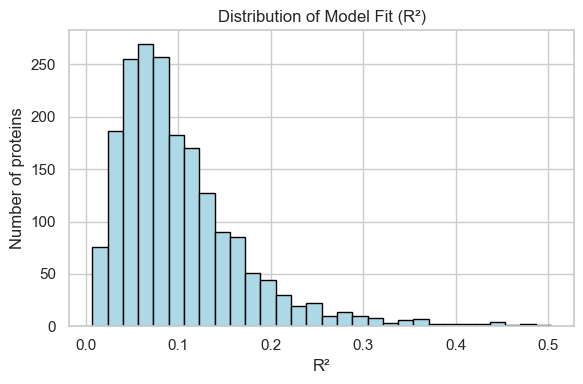

In [45]:
plt.figure(figsize=(6,4))
plt.hist(res_df["R_squared"], bins=30, color = "lightblue", edgecolor="black")
plt.xlabel("R²")
plt.ylabel("Number of proteins")
plt.title("Distribution of Model Fit (R²)")

plt.tight_layout()
plt.savefig("output/R2_distribution.png", dpi=300)
plt.savefig("output/R2_distribution.pdf")

plt.tight_layout()
plt.savefig("output/Distr_of_R2.png", dpi=300)
plt.savefig("output/Distr_of_R2.pdf")

plt.show()

_R2 - log2FC scatterplot_

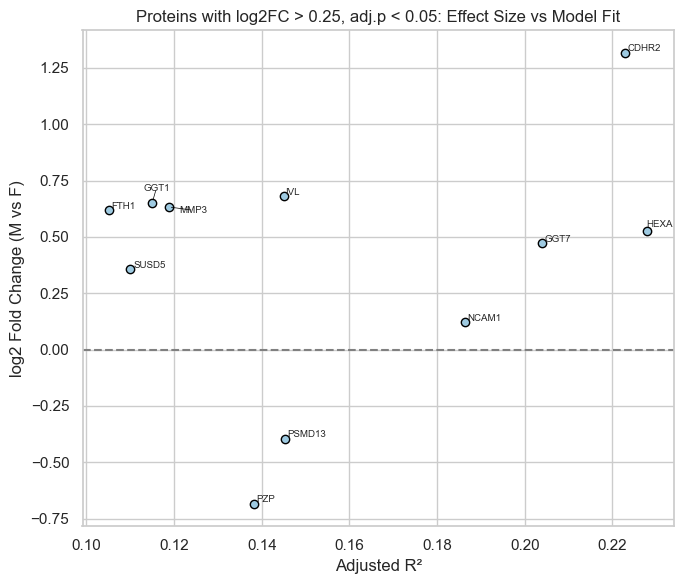

In [46]:
plot_df = res_df[
    (res_df["adj_pvalue"] < 0.05)
].copy()
label_df = plot_df.sort_values("adj_pvalue").head(20)

import matplotlib.pyplot as plt

plt.figure(figsize=(7,6))

plt.scatter(
    plot_df["adj_R_squared"],
    plot_df["log2FC"],
    color="#9ecae1",
    edgecolor="black"
)

plt.axhline(0, linestyle="--", color="grey")

texts = []

for _, row in label_df.iterrows():
    texts.append(
        plt.text(
            row["adj_R_squared"],
            row["log2FC"],
            row["Protein"],
            fontsize=7
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
    expand_text=(1.2, 1.4),
    expand_points=(1.2, 1.4),
    force_text=(0.5, 0.8),
    force_points=(0.2, 0.5)
)
    
plt.xlabel("Adjusted R²")
plt.ylabel("log2 Fold Change (M vs F)")
plt.title(f"Proteins with log2FC > {fc_thresh}, adj.p < {p_thresh}: Effect Size vs Model Fit")

plt.tight_layout()

plt.savefig("output/log2FC_vs_R2adj_labeled.png", dpi=300)
plt.savefig("output/log2FC_vs_R2adj_labeled.pdf")

plt.show()

__Cohen's D analysis__

~0.2 - small effect <br>
~0.5 - medium <br>
~0.8 - large <br>
1.0 < - very strong biological separation <br>


In [47]:
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    vx = np.var(x, ddof=1)
    vy = np.var(y, ddof=1)

    pooled = np.sqrt(((nx - 1)*vx + (ny - 1)*vy) / (nx + ny - 2))

    return (np.mean(x) - np.mean(y)) / pooled

In [48]:
results = []

for protein in expr.columns:
    y = expr[protein]

    df_model = design_df.copy()
    df_model["y"] = y

    df_model = df_model.apply(pd.to_numeric, errors="coerce").dropna()

    if df_model.shape[0] < 10:
        continue

    y_clean = df_model["y"].astype(float)
    X_clean = df_model.drop(columns=["y"]).astype(float)

    X_clean = sm.add_constant(X_clean)

    model = sm.OLS(y_clean.values, X_clean.values)
    fit = model.fit()

    # residuals = covariate-adjusted signal
    df_model["residuals"] = fit.resid

    male = df_model[df_model["Sex"] == 1]["residuals"]
    female = df_model[df_model["Sex"] == 0]["residuals"]

    if len(male) < 5 or len(female) < 5:
        continue

    d = cohens_d(male, female)

    results.append([protein, d])

cohen_df = pd.DataFrame(results, columns=["Protein", "CohensD"])

/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_99826/4211414013.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return (np.mean(x) - np.mean(y)) / pooled
/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_99826/4211414013.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return (np.mean(x) - np.mean(y)) / pooled
/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_99826/4211414013.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return (np.mean(x) - np.mean(y)) / pooled
/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_99826/4211414013.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return (np.mean(x) - np.mean(y)) / pooled
/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_99826/4211414013.py:10: RuntimeWarning: invalid value encountered in scalar divide
  return (np.mean(x) - np.mean(y)) / pooled
/var/folders/7h/dvymb3m50bzg0j9yyrdvvn000000gn/T/ipykernel_99826/42114

__Function for Differential analyses__

limma-like differential analysis

In [49]:
def differential_analysis(
    data,
    mat,
    feature,
    subset_column=None,
    subset_value=None,
    tp_contrast=None,
    conf_factors=["Country", "cancer_type", "TP", "toxicity"]
):

    # ---------------------------
    # Helper: Cohen's D
    # ---------------------------
    def cohens_d(x, y):
        nx, ny = len(x), len(y)
        if nx < 2 or ny < 2:
            return np.nan

        vx, vy = np.var(x, ddof=1), np.var(y, ddof=1)
        pooled = np.sqrt(((nx - 1)*vx + (ny - 1)*vy) / (nx + ny - 2))

        if pooled == 0:
            return np.nan

        return (np.mean(x) - np.mean(y)) / pooled
    

    # ---------------------------
    # Build design matrix
    # ---------------------------
    design_cols = [feature] + conf_factors
    design_df = data[design_cols].copy()

    # subsetting
    if subset_column is not None and subset_value is not None:
        design_df = design_df[design_df[subset_column] == subset_value].copy()
        mat = mat.loc[design_df.index]
        data = data.loc[design_df.index].copy()    

    if feature == "Sex":
        # Encode Sex (M=1, F=0)
        design_df["Sex"] = design_df["Sex"].map({"M": 1, "F": 0})

        # One-hot encode
        design_df = pd.get_dummies(
            design_df,
            columns=conf_factors,
            drop_first=True
        )

        # Ensure numeric
        design_df = design_df.apply(pd.to_numeric, errors="coerce")

    if feature == "toxicity":
        # Encode toxicity (yes=1, no=0)
        design_df["toxicity"] = design_df["toxicity"].map({"yes": 1, "no": 0})

        # One-hot encode
        design_df = pd.get_dummies(
            design_df,
            columns=conf_factors,
            drop_first=True
        )

        # Ensure numeric
        design_df = design_df.apply(pd.to_numeric, errors="coerce")
    
    if tp_contrast != None and feature == "TP":
        if tp_contrast == "T2_vs_T0":
            design_df = design_df[design_df["TP"].isin(["T0", "T2"])].copy()
            # Encode TP
            design_df["TP"] = design_df["TP"].map({"T2": 1, "T0": 0})

            # One-hot encode
            design_df = pd.get_dummies(
                design_df,
                columns=conf_factors,
                drop_first=True
            )

            # Ensure numeric
            design_df = design_df.apply(pd.to_numeric, errors="coerce")

        if tp_contrast == "T1_vs_T0":
            design_df = design_df[design_df["TP"].isin(["T0", "T1"])].copy()
            # Encode TP
            design_df["TP"] = design_df["TP"].map({"T1": 1, "T0": 0})

            # One-hot encode
            design_df = pd.get_dummies(
                design_df,
                columns=conf_factors,
                drop_first=True
            )

            # Ensure numeric
            design_df = design_df.apply(pd.to_numeric, errors="coerce")
    
    design_df = design_df.apply(pd.to_numeric, errors="coerce")
    print(f"Design matrix shape: {design_df.head(3)}")

    # ---------------------------
    # Align data
    # ---------------------------
    common_idx = design_df.index.intersection(mat.index)
    design_df = design_df.loc[common_idx]
    mat = mat.loc[common_idx]
    data = data.loc[common_idx].copy()
    mat = mat.loc[common_idx].copy()

    # ---------------------------
    # Define and print comparison
    # ---------------------------
    comparison_str = ""

    if feature == "Sex":
        comparison_str = "Sex: M vs F"

    elif feature == "TP" and tp_contrast is not None:
        if tp_contrast == "T2_vs_T0":
            comparison_str = "TP: T2 vs T0"
        elif tp_contrast == "T1_vs_T0":
            comparison_str = "TP: T1 vs T0"

    else:
        # Generic fallback (for other features)
        unique_vals = data[feature].dropna().unique()
        if len(unique_vals) == 2:
            comparison_str = f"{feature}: {unique_vals[1]} vs {unique_vals[0]}"
        else:
            comparison_str = f"{feature}: {unique_vals}"

    # Add subset info if present
    if subset_column is not None and subset_value is not None:
        comparison_str += f" | subset: {subset_column} = {subset_value}"

    print(f"\n🔬 Running differential analysis: {comparison_str}")
    print(f"Samples used: {len(common_idx)}\n")

    # ---------------------------
    # Main loop
    # ---------------------------
    results = []

    for protein in mat.columns:
        y = mat[protein]

        df_model = design_df.copy()
        df_model = df_model.join(y.rename("y"), how="inner")

        df_model = df_model.apply(pd.to_numeric, errors="coerce").dropna()

        if df_model.shape[0] < 10:
            continue

        y_clean = df_model["y"].astype(float)
        X_clean = df_model.drop(columns=["y"]).astype(float)
        
        X_clean = sm.add_constant(X_clean)

        try:
            fit = sm.OLS(y_clean.values, X_clean.values).fit()
        except:
            continue

        col_names = X_clean.columns.tolist()
        if feature not in col_names:
            continue

        feat_idx = col_names.index(feature)

        coef = fit.params[feat_idx]
        pval = fit.pvalues[feat_idx]

        # Skip bad p-values
        if np.isnan(pval) or np.isinf(pval) or pval <= 0:
            continue

        r2 = fit.rsquared
        r2_adj = fit.rsquared_adj

        # Residuals for adjusted Cohen's D
        df_model["residuals"] = fit.resid

        group_vals = df_model[feature].unique()
        if len(group_vals) != 2:
            continue

        g1, g2 = group_vals

        group1 = df_model[df_model[feature] == g1]["residuals"]
        group2 = df_model[df_model[feature] == g2]["residuals"]

        d = cohens_d(group1, group2)

        results.append([protein, coef, pval, r2, r2_adj, d])

    # ---------------------------
    # Build result table
    # ---------------------------
    res_df = pd.DataFrame(
        results,
        columns=[
            "Protein",
            "log2FC",
            "pvalue",
            "R2",
            "R2_adj",
            "CohensD"
        ]
    )

    if len(res_df) == 0:
        print("⚠️ No valid proteins found. Check filtering/design matrix.")
        return res_df

    # Clean p-values
    res_df = res_df.replace([np.inf, -np.inf], np.nan)
    res_df = res_df.dropna(subset=["pvalue"])

    # BH correction
    if res_df.shape[0] > 0:
        res_df["adj_pvalue"] = multipletests(res_df["pvalue"].values, method="fdr_bh")[1]
    else:
        res_df["adj_pvalue"] = []

    # Sort
    res_df = res_df.sort_values("adj_pvalue")
    res_df["comparison"] = comparison_str
    res_df = res_df[["Protein", "log2FC", "pvalue", "adj_pvalue", "R2", "R2_adj", "CohensD", "comparison"]]

    # Filter column

    if subset_column is not None and subset_value is not None:
        filter_str = f"{subset_column} = {subset_value}"
    else:
        filter_str = "None"
    res_df["filter"] = filter_str

    # Confounders column (as list → string for readability/export)
    res_df["conf_factors"] = [conf_factors] * len(res_df)

    return res_df

In [50]:
sex_all = differential_analysis(
    data=data,
    mat=expr,
    feature="Sex",
    conf_factors=["Country", "cancer_type", "TP", "toxicity"]
)

t1_vs_t0_all = differential_analysis(
    data=data,
    mat=expr,
    feature="TP",
    tp_contrast="T1_vs_T0",
    conf_factors=["Country", "cancer_type", "Sex", "toxicity"])

t2_vs_t0_all = differential_analysis(
    data=data,
    mat=expr,
    feature="TP",
    tp_contrast="T2_vs_T0",
    conf_factors=["Country", "cancer_type", "Sex", "toxicity"])

t0_tox_vs_notox = differential_analysis(
    data=data,
    mat=expr,
    feature="toxicity",
    subset_column="TP",
    subset_value="T0",
    conf_factors=["Country", "cancer_type", "Sex", "TP"])


data_t0_tox = data[data["toxicity"] == "yes"]
expr_t0_tox = expr.loc[data_t0_tox.index]
t0_tox_male_vs_female = differential_analysis(
    data=data_t0_tox,
    mat=expr_t0_tox,
    feature="Sex",
    subset_column="TP",
    subset_value="T0",
    conf_factors=["Country", "cancer_type", "TP"])

data_t0_wo_tox = data[data["toxicity"] == "no"]
expr_t0_wo_tox = expr.loc[data_t0_wo_tox.index]
t0_wo_tox_male_vs_female = differential_analysis(
    data=data_t0_wo_tox,
    mat=expr_t0_wo_tox,
    feature="Sex",
    subset_column="TP",
    subset_value="T0",
    conf_factors=["Country", "cancer_type", "TP"])

male_t2_vs_t0 = differential_analysis(
    data=data,
    mat=expr,
    feature="TP",
    subset_column="Sex",
    tp_contrast="T2_vs_T0",
    subset_value="M",
    conf_factors=["Country", "cancer_type", "Sex", "toxicity"])

female_t2_vs_t0 = differential_analysis(
    data=data,
    mat=expr,
    feature="TP",
    tp_contrast="T2_vs_T0",
    subset_column="Sex",
    subset_value="F",
    conf_factors=["Country", "cancer_type", "Sex", "toxicity"])

male_t1_vs_t0 = differential_analysis(
    data=data,
    mat=expr,
    feature="TP",
    subset_column="Sex",
    tp_contrast="T1_vs_T0",
    subset_value="M",
    conf_factors=["Country", "cancer_type", "Sex", "toxicity"])

female_t1_vs_t0 = differential_analysis(
    data=data,
    mat=expr,
    feature="TP",
    tp_contrast="T1_vs_T0",
    subset_column="Sex",
    subset_value="F",
    conf_factors=["Country", "cancer_type", "Sex", "toxicity"])

tox_t1_vs_t0 = differential_analysis(
    data=data,
    mat=expr,
    feature="TP",
    subset_column="toxicity",
    tp_contrast="T1_vs_T0",
    subset_value="yes",
    conf_factors=["Country", "cancer_type", "Sex", "toxicity"])

wotox_t1_vs_t0 = differential_analysis(
    data=data,
    mat=expr,
    feature="TP",
    subset_column="toxicity",
    tp_contrast="T1_vs_T0",
    subset_value="no",
    conf_factors=["Country", "cancer_type", "Sex", "toxicity"])



Design matrix shape:             Sex  Country_ITA  Country_NOR  Country_SWE  cancer_type_Lung  \
CF ID                                                                      
XCHEJF_001  1.0        False        False         True             False   
XCHEJF_001  1.0        False        False         True             False   
XCHEJF_002  NaN        False        False         True             False   

            cancer_type_Melanoma  TP_T1  TP_T2  toxicity_yes  
CF ID                                                         
XCHEJF_001                  True  False  False         False  
XCHEJF_001                  True  False  False         False  
XCHEJF_002                  True   True  False         False  

🔬 Running differential analysis: Sex: M vs F
Samples used: 235



/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Design matrix shape:             TP  Country_ITA  Country_NOR  Country_SWE  cancer_type_Lung  \
CF ID                                                                     
XCHEJF_001   0        False        False         True             False   
XCHEJF_001   0        False        False         True             False   
XCHEJF_002   1        False        False         True             False   

            cancer_type_Melanoma  Sex_M  toxicity_yes  
CF ID                                                  
XCHEJF_001                  True   True         False  
XCHEJF_001                  True   True         False  
XCHEJF_002                  True  False         False  

🔬 Running differential analysis: TP: T1 vs T0
Samples used: 202



/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Design matrix shape:             TP  Country_ITA  Country_NOR  Country_SWE  cancer_type_Lung  \
CF ID                                                                     
XCHEJF_001   0        False        False         True             False   
XCHEJF_001   0        False        False         True             False   
XCHEJF_003   0        False        False         True             False   

            cancer_type_Melanoma  Sex_M  toxicity_yes  
CF ID                                                  
XCHEJF_001                  True   True         False  
XCHEJF_001                  True   True         False  
XCHEJF_003                  True   True         False  

🔬 Running differential analysis: TP: T2 vs T0
Samples used: 144



...

/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Design matrix shape:             TP  Country_ITA  Country_NOR  Country_SWE  cancer_type_Lung  \
CF ID                                                                     
XCHEJF_005   0        False        False         True             False   
XCHEJF_005   0        False        False         True             False   
XCHEJF_006   1        False        False         True             False   

            cancer_type_Melanoma  Sex_M  
CF ID                                    
XCHEJF_005                  True   True  
XCHEJF_005                  True   True  
XCHEJF_006                  True  False  

🔬 Running differential analysis: TP: T1 vs T0 | subset: toxicity = yes
Samples used: 144



/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


Design matrix shape:             TP  Country_ITA  Country_NOR  Country_SWE  cancer_type_Melanoma  \
CF ID                                                                         
XCHEJF_001   0        False        False         True                  True   
XCHEJF_001   0        False        False         True                  True   
XCHEJF_002   1        False        False         True                  True   

            Sex_M  
CF ID              
XCHEJF_001   True  
XCHEJF_001   True  
XCHEJF_002  False  

🔬 Running differential analysis: TP: T1 vs T0 | subset: toxicity = no
Samples used: 58



/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/Users/szabolcshetey/Desktop/Hanna/GDefiner/scripts/plasma_proteomics/.venv/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss


__Function for Volcano plot__

In [51]:
def plot_volcano(res_table, output,
                 string_for_up,
                 string_for_down,
                 fc_thresh=0.1,
                 p_thresh=0.05):

    res_df = res_table.copy()

    # ---------------------------
    # Prepare data
    # ---------------------------

    res_df["-log10_p"] = -np.log10(res_df["adj_pvalue"])

    # Category assignment
    def categorize(row):

        if row["adj_pvalue"] < p_thresh and row["log2FC"] > fc_thresh:
            return f"Enriched in {string_for_up}"
        elif row["adj_pvalue"] < p_thresh and row["log2FC"] < -fc_thresh:
            return f"Enriched in {string_for_down}"
        else:
            return "Non-significant"

    res_df["category"] = res_df.apply(categorize, axis=1)

    # ---------------------------
    # Extract metadata for titles
    # ---------------------------

    comparison = res_df["comparison"].iloc[0] if "comparison" in res_df.columns else ""

    if "conf_factors" in res_df.columns:
        conf = res_df["conf_factors"].iloc[0]
        if isinstance(conf, list):
            conf = ", ".join(conf)
    else:
        conf = ""

    # ---------------------------
    # Plot
    # ---------------------------

    palette = {
        f"Enriched in {string_for_up}": "#3182bd",
        f"Enriched in {string_for_down}": "#de2d26",
        "Non-significant": "#cccccc"
    }

    plt.figure(figsize=(7,6))
    sns.scatterplot(
        data=res_df,
        x="log2FC",
        y="-log10_p",
        hue="category",
        palette=palette,
        s=50,
        edgecolor="black",
        linewidth=0.3
    )

    # Threshold lines
    plt.axhline(-np.log10(p_thresh), linestyle="--", color="grey")
    plt.axvline(fc_thresh, linestyle="--", color="grey")
    plt.axvline(-fc_thresh, linestyle="--", color="grey")
    #plt.xlim(-2.5, 2.5)
    plt.xlabel("log2 Fold Change")
    plt.ylabel("-log10(adj. p-value)")

    # ---------------------------
    # Labels (ggrepel-style)
    # ---------------------------

    label_df = res_df[
        (res_df["adj_pvalue"] < p_thresh) &
        (abs(res_df["log2FC"]) > fc_thresh)
    ].copy()

    texts = []
    for _, row in label_df.iterrows():
        texts.append(
            plt.text(
                row["log2FC"],
                row["-log10_p"],
                row["Protein"],
                fontsize=7
            )
        )

    adjust_text(
        texts,
        arrowprops=dict(arrowstyle="-", color="black", lw=0.5),
        expand_text=(1.4, 1.6),
        expand_points=(1.2, 1.4),
        force_text=(0.5, 0.8),
        force_points=(0.2, 0.5),
        only_move={"text": "xy"}
    )

    # ---------------------------
    # Titles
    # ---------------------------

    plt.suptitle(comparison, fontsize=12)
    plt.title(f"Adjusted for: {conf}", fontsize=9)

    # Legend
    plt.legend(title="", loc="upper left")
    plt.tight_layout()

    # ---------------------------
    # Save outputs
    # ---------------------------

    os.makedirs("output/ols_volcano", exist_ok=True)
    png_path = f"output/ols_volcano/{output}.png"
    pdf_path = f"output/ols_volcano/{output}.pdf"

    plt.savefig(png_path, dpi=300)
    plt.savefig(pdf_path)
    plt.show()

    return png_path, pdf_path

<font color='green'>__Male vs Female (all)__</font>

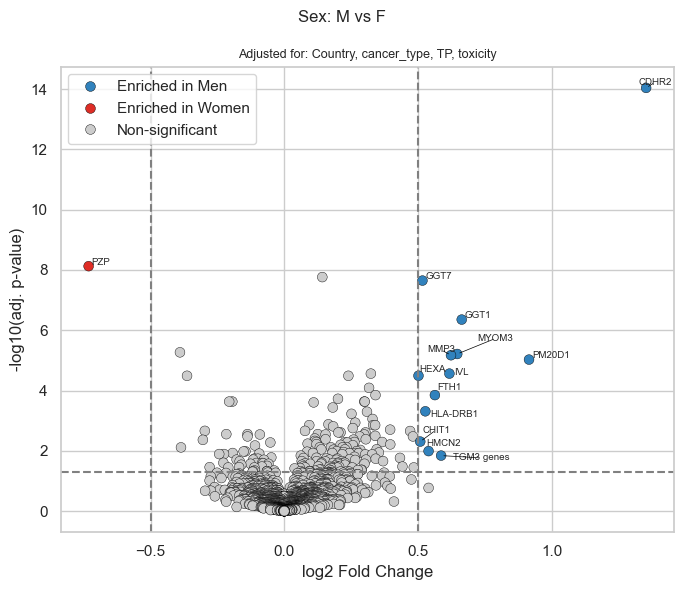

('output/ols_volcano/Diff_prot_volcano-male_vs_female_all.png',
 'output/ols_volcano/Diff_prot_volcano-male_vs_female_all.pdf')

In [52]:
plot_volcano(res_table=sex_all, 
             output="Diff_prot_volcano-male_vs_female_all", 
             string_for_up="Men", 
             string_for_down="Women", 
             fc_thresh=0.5, 
             p_thresh=0.05)

<font color='green'>__T1 vs T0 (all)__</font>

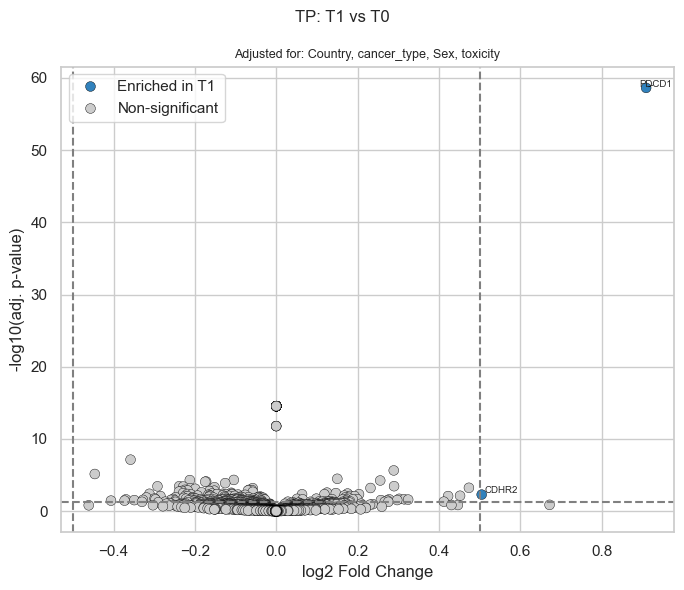

('output/ols_volcano/Diff_prot_volcano-T1_vs_T0_all.png',
 'output/ols_volcano/Diff_prot_volcano-T1_vs_T0_all.pdf')

In [53]:
plot_volcano(res_table=t1_vs_t0_all, 
             output="Diff_prot_volcano-T1_vs_T0_all", 
             string_for_up="T1", 
             string_for_down="T0", 
             fc_thresh=0.5, 
             p_thresh=0.05)

<font color='green'>__T2 vs T0 (all)__</font>

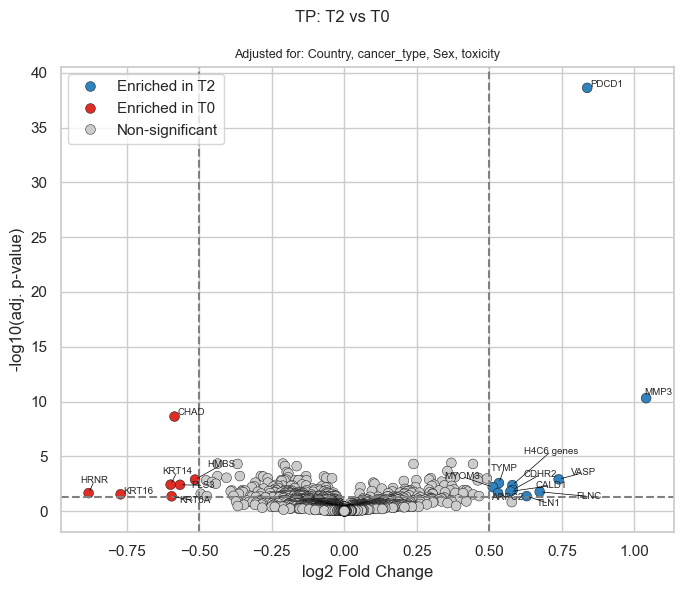

('output/ols_volcano/Diff_prot_volcano-T2_vs_T0_all.png',
 'output/ols_volcano/Diff_prot_volcano-T2_vs_T0_all.pdf')

In [54]:
plot_volcano(res_table=t2_vs_t0_all, 
             output="Diff_prot_volcano-T2_vs_T0_all", 
             string_for_up="T2", 
             string_for_down="T0", 
             fc_thresh=0.5, 
             p_thresh=0.05)

<font color='green'>__Toxicity vs Without Toxicity (T0)__</font>

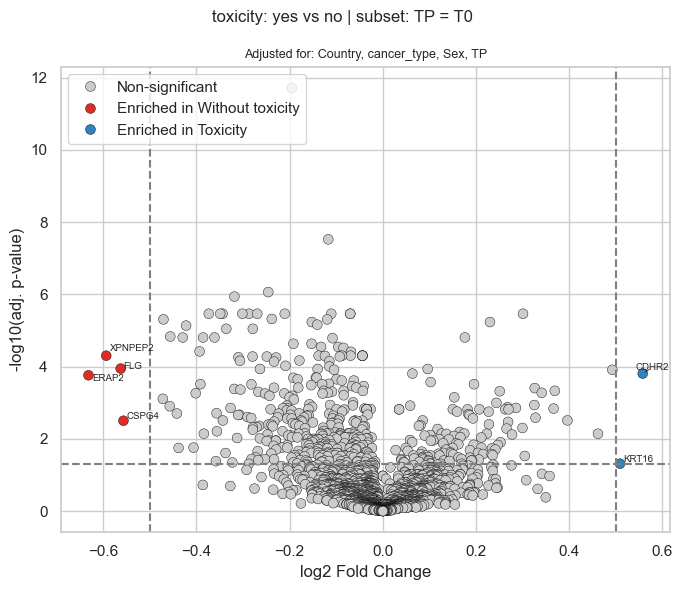

('output/ols_volcano/Diff_prot_volcano-tox_vs_notox_t0.png',
 'output/ols_volcano/Diff_prot_volcano-tox_vs_notox_t0.pdf')

In [55]:
plot_volcano(res_table=t0_tox_vs_notox, 
             output="Diff_prot_volcano-tox_vs_notox_t0", 
             string_for_up="Toxicity", 
             string_for_down="Without toxicity", 
             fc_thresh=0.5, 
             p_thresh=0.05)

<font color='green'>__Male vs Female (T0, toxicity)__</font>

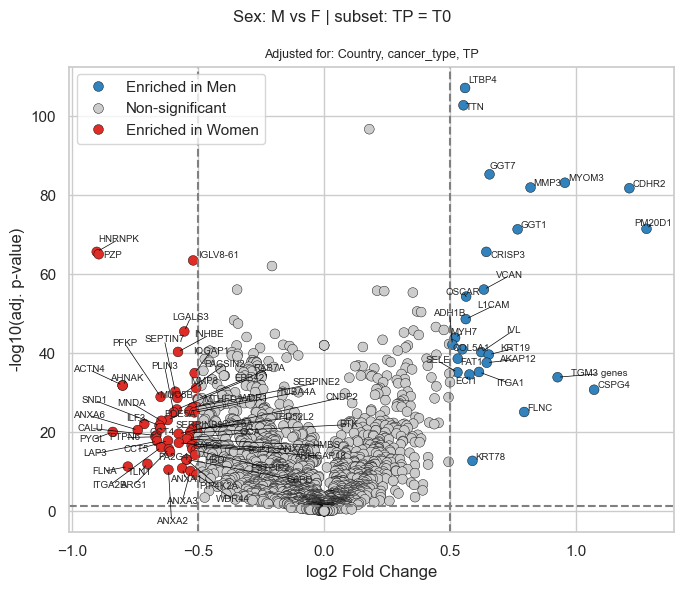

('output/ols_volcano/Diff_prot_volcano-male_vs_female_t0_tox.png',
 'output/ols_volcano/Diff_prot_volcano-male_vs_female_t0_tox.pdf')

In [56]:
plot_volcano(res_table=t0_tox_male_vs_female, 
             output="Diff_prot_volcano-male_vs_female_t0_tox", 
             string_for_up="Men", 
             string_for_down="Women", 
             fc_thresh=0.5, 
             p_thresh=0.05)

<font color='green'>__Male vs Female (T0, without toxicity)__</font>

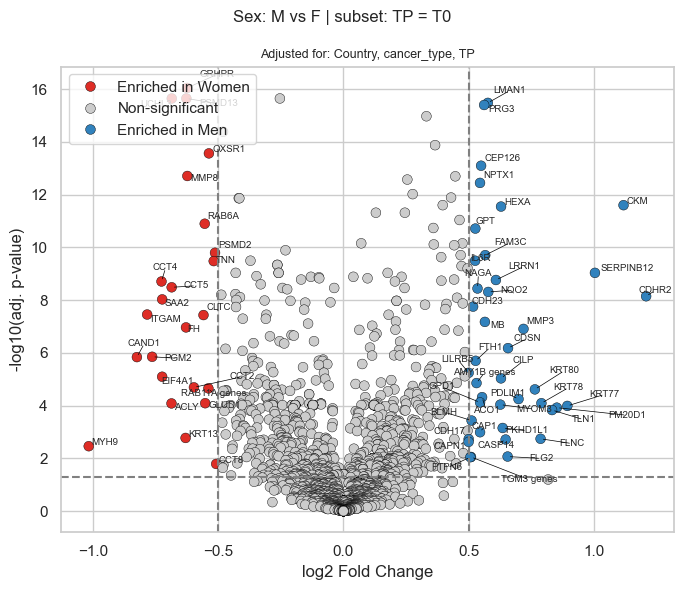

('output/ols_volcano/Diff_prot_volcano-male_vs_female_t0_wotox.png',
 'output/ols_volcano/Diff_prot_volcano-male_vs_female_t0_wotox.pdf')

In [57]:
plot_volcano(res_table=t0_wo_tox_male_vs_female, 
             output="Diff_prot_volcano-male_vs_female_t0_wotox", 
             string_for_up="Men", 
             string_for_down="Women", 
             fc_thresh=0.5, 
             p_thresh=0.05)

<font color='green'>__T2 vs T0 (Male)__</font>

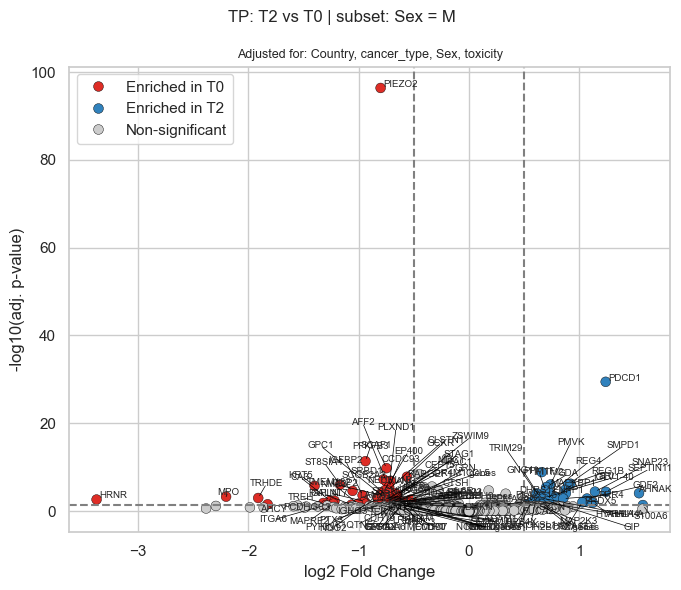

('output/ols_volcano/Diff_prot_volcano-T2_vs_T0_male.png',
 'output/ols_volcano/Diff_prot_volcano-T2_vs_T0_male.pdf')

In [58]:
plot_volcano(res_table=male_t2_vs_t0, 
             output="Diff_prot_volcano-T2_vs_T0_male", 
             string_for_up="T2", 
             string_for_down="T0", 
             fc_thresh=0.5, 
             p_thresh=0.05)

<font color='green'>__T2 vs T0 (Female)__</font>

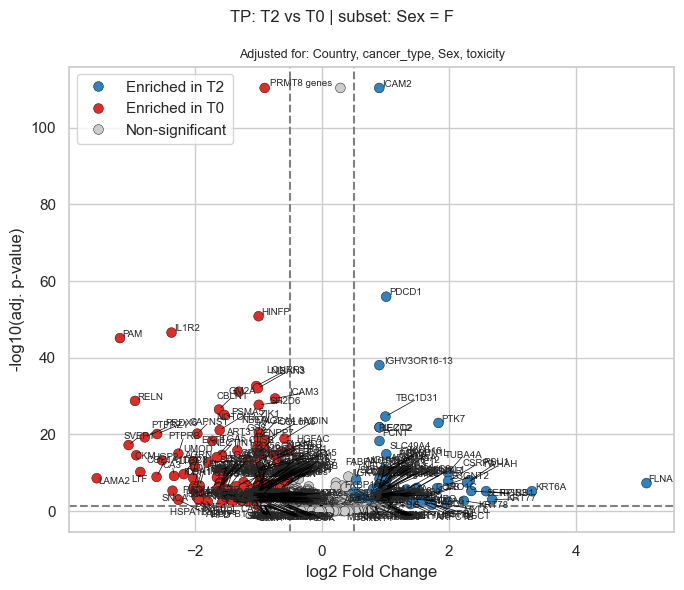

('output/ols_volcano/Diff_prot_volcano-T2_vs_T0_female.png',
 'output/ols_volcano/Diff_prot_volcano-T2_vs_T0_female.pdf')

In [59]:
plot_volcano(res_table=female_t2_vs_t0, 
             output="Diff_prot_volcano-T2_vs_T0_female", 
             string_for_up="T2", 
             string_for_down="T0", 
             fc_thresh=0.5, 
             p_thresh=0.05)

<font color='green'>__T1 vs T0 (Male)__</font>

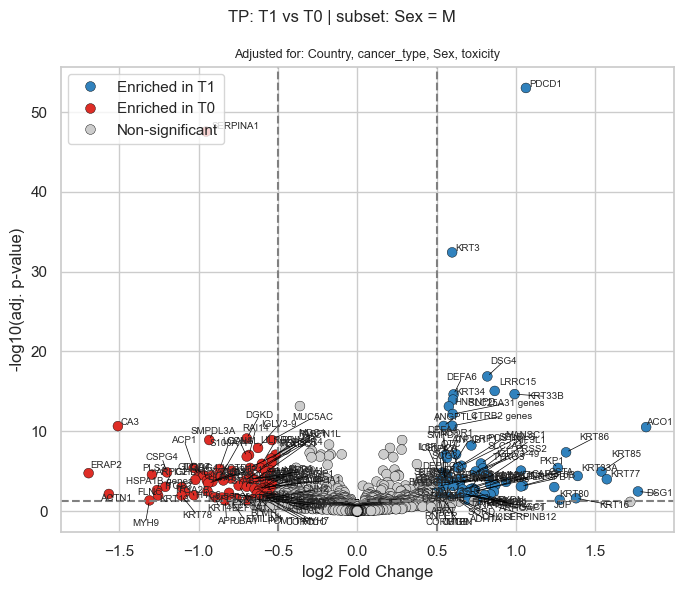

('output/ols_volcano/Diff_prot_volcano-T1_vs_T0_male.png',
 'output/ols_volcano/Diff_prot_volcano-T1_vs_T0_male.pdf')

In [60]:
plot_volcano(res_table=male_t1_vs_t0, 
             output="Diff_prot_volcano-T1_vs_T0_male", 
             string_for_up="T1", 
             string_for_down="T0", 
             fc_thresh=0.5, 
             p_thresh=0.05)

<font color='green'>__T1 vs T0 (Female)__</font>

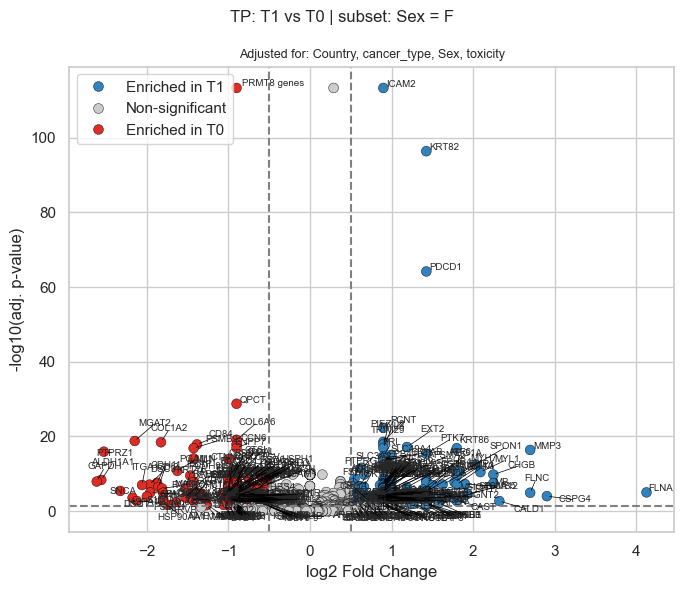

('output/ols_volcano/Diff_prot_volcano-T1_vs_T0_female.png',
 'output/ols_volcano/Diff_prot_volcano-T1_vs_T0_female.pdf')

In [61]:
plot_volcano(res_table=female_t1_vs_t0, 
             output="Diff_prot_volcano-T1_vs_T0_female", 
             string_for_up="T1", 
             string_for_down="T0", 
             fc_thresh=0.5, 
             p_thresh=0.05)

<font color='green'>__T1 vs T0 (toxicity)__</font>

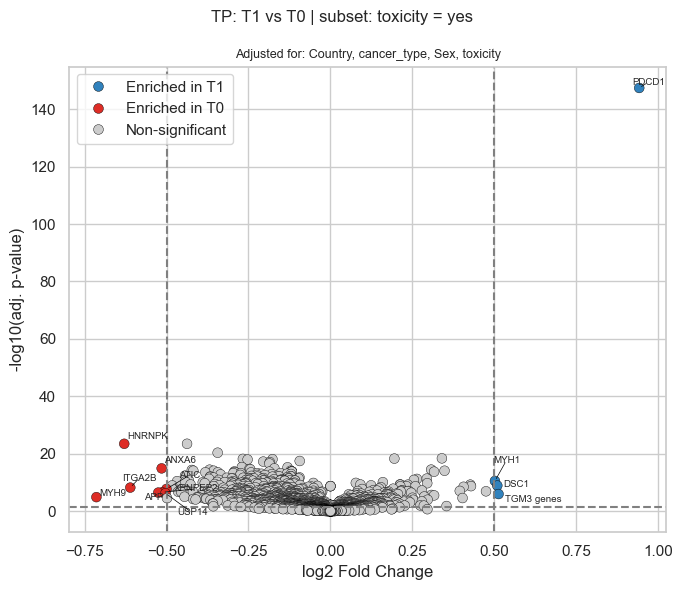

('output/ols_volcano/Diff_prot_volcano-T1_vs_T0_tox.png',
 'output/ols_volcano/Diff_prot_volcano-T1_vs_T0_tox.pdf')

In [62]:
plot_volcano(res_table=tox_t1_vs_t0, 
             output="Diff_prot_volcano-T1_vs_T0_tox", 
             string_for_up="T1", 
             string_for_down="T0", 
             fc_thresh=0.5, 
             p_thresh=0.05)

<font color='green'>__T1 vs T0 (without toxicity)__</font>

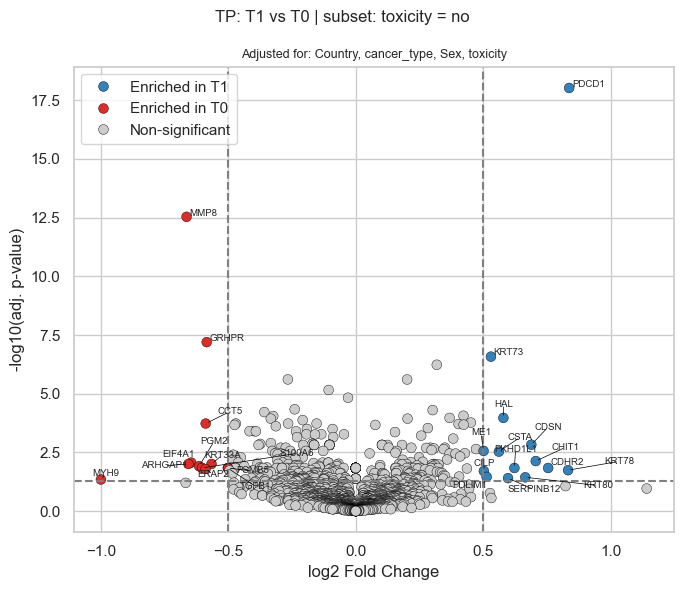

('output/ols_volcano/Diff_prot_volcano-T1_vs_T0_wotox.png',
 'output/ols_volcano/Diff_prot_volcano-T1_vs_T0_wotox.pdf')

In [63]:
plot_volcano(res_table=wotox_t1_vs_t0, 
             output="Diff_prot_volcano-T1_vs_T0_wotox", 
             string_for_up="T1", 
             string_for_down="T0", 
             fc_thresh=0.5, 
             p_thresh=0.05)